In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler


def eda(df):
    print("-" * 60)
    print("DATASET OVERVIEW")

    print("Dimensions:", df.shape)
    print("\nFirst 5 rows:")
    print(df.head())

    print("\nColumns:")
    for col in df.columns:
        print(col)

    dup = df.duplicated().sum()

    print("\nDuplicate rows:", dup)

    if dup > 0:
        df = df.drop_duplicates()
        print("Duplicate rows removed.")

    print("-" * 60)
    print("MISSING VALUE ANALYSIS")

    missing = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    print("\n")
    print(f"Number of missing values: {missing}")

    # Plot missing values
    plt.figure(figsize=(10, 5))
    plt.bar(df.columns, df.isnull().sum())
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.title("Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    
    #Remove columns with > 50% missing values
    
    missing_threshold = 50

    columns_to_drop = missing_percentage[missing_percentage > missing_threshold].index.tolist()

    if columns_to_drop:
        print("\nColumns removed because of excessive missing values:")
        for col in columns_to_drop: 
            print("column: " + col + " missing percentage: " + missing_percentage[col])
        df = df.drop(columns=columns_to_drop)

    else:
        print("\nNo columns have more than 50% missing values.")

    #Remove constant columns

    constant_columns = []    

    for col in df.columns:
            if df[col].nunique(dropna=False) <= 1:
                constant_columns.append(col)

    if constant_columns:
        print("\nConstant columns removed:")
        for col in constant_columns:
            print(col)
        df = df.drop(columns=constant_columns)

 
    #Seperate numerical and categorical features

    num_cols = df.select_dtypes(include=np.number).columns.tolist()

    cat_cols = df.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    print("\nNumerical columns:")
    print(num_cols)

    print("\nCategorical columns:")
    print(cat_cols)

    
    #Missing value imputation
    
    print("-" * 60)
    print("MISSING VALUE IMPUTATION")

    for col in num_cols:
        if df[col].isnull().sum() > 0:
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)

    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            mode = df[col].mode()
            if not mode.empty:
                mode_value = mode[0]
                df[col] = df[col].fillna(mode_value)

    print("Missing values imputed!")

    
    # outlier handling
    

    print("-" * 60)
    print("OUTLIER DETECTION")

    
    outlier_percentage_threshold = 15

    for col in num_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_df = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        )
        out_cnt = outlier_df.sum()
        outlier_percentage = (out_cnt / len(df)) * 100
        print(f"{col}: {out_cnt} outliers, percentage: {outlier_percentage}")

        if outlier_percentage == 0:
            print("No outliers detected.")

        elif outlier_percentage <= outlier_percentage_threshold:
            median_value = df[col].median()
            df.loc[outlier_df, col] = median_value

            print("Few outliers detected.")
            print(f"Replaced with median ({median_value}).")

        elif outlier_percentage >= outlier_percentage_threshold:

            df.loc[df[col] < lower_bound, col] = lower_bound
            df.loc[df[col] > upper_bound, col] = upper_bound

            print("Moderate outliers detected.")
            print("Values changed to IQR boundaries")

    print("-" * 60)
    print("NUMERICAL FEATURES VISUALIZATION")
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"{col} - Distribution")
        axes[0].set_xlabel(col)

        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"{col} - Boxplot")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

    # Numerical feature analysis

    print("-" * 60)
    print("NUMERICAL FEATURE TRANSFORMATION")

    for col in num_cols:
        skewness = df[col].skew()
        print(f"{col}: skewness = {skewness}")
        if abs(skewness) > 1:
            if (df[col] >= 0).all():
                df[col] = np.log1p(df[col])
                print("Highly skewed and non-negative.")
                print("Applied log1p transformation.")
            else:
                scaler = StandardScaler()
                df[[col]] = scaler.fit_transform(df[[col]])

                print("Highly skewed but contains negative values. Applied StandardScaler.")
        else:
            scaler = StandardScaler()
            df[[col]] = scaler.fit_transform(df[[col]])
            print("Distribution is reasonably symmetric.")
            print("Applied StandardScaler.")

    #Categorical feature analysis

    print("-" * 60)
    print("CATEGORICAL FEATURE ANALYSIS")

    for col in cat_cols:
        counts = df[col].value_counts()

        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=df,
            x=col,
            order=counts.index
        )

        plt.title(f"Count Plot - {col}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    
    # Encode categorical values
    
    print("-" * 60)
    print("CATEGORICAL ENCODING")

    for col in cat_cols:
        unique_count = df[col].nunique()
        if unique_count == 2:
            values = df[col].unique()
            mapping = {values[0]: 0, values[1]: 1}
            df[col] = df[col].map(mapping)
            print(f"{col}: Binary encoding -> {mapping}")

        else:

            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
            df = pd.concat([df.drop(columns=[col]), dummies],axis=1)
            print(f"{col}: One-hot encoded ")
            print(f"{unique_count} categories")


    # Final dataset

    print("-" * 60)
    print("FINAL DATASET")

    print("Final dimensions:", df.shape)

    print("Remaining columns:")
    print(df.columns.tolist())

    print("Remaining missing values:")
    print(df.isnull().sum())

    print("Final dataframe:")
    print(df.head())

    return df

In [10]:
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import chi2

def feature_selection(df, target):
    X = df.drop(columns=[target])
    Y = df[target]

    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    if Y.dtype in ['int64', 'float64']:
        selector = SelectKBest(score_func=f_regression, k='all')
        selector.fit(X[num_cols], Y)
        scores = pd.DataFrame({ "Feature": num_cols, "Regression Score": selector.scores_,})
        print(scores)

    else:
        if len(num_cols) > 0:
            selector = SelectKBest( score_func=f_classif, k='all')
            selector.fit(X[num_cols], Y)
            scores = pd.DataFrame({ "Feature": num_cols, "ANOVA Score": selector.scores_,})
            print(scores)
        if len(cat_cols) > 0:
            X_cat = X[cat_cols]
            selector = SelectKBest(score_func=chi2, k='all')
            selector.fit(X_cat, Y)
            chi = pd.DataFrame({ "Feature": X_cat.columns, "Chi2 Score": selector.scores_})
            print(chi)

In [11]:
data = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

------------------------------------------------------------
DATASET OVERVIEW
Dimensions: (367, 12)

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0        

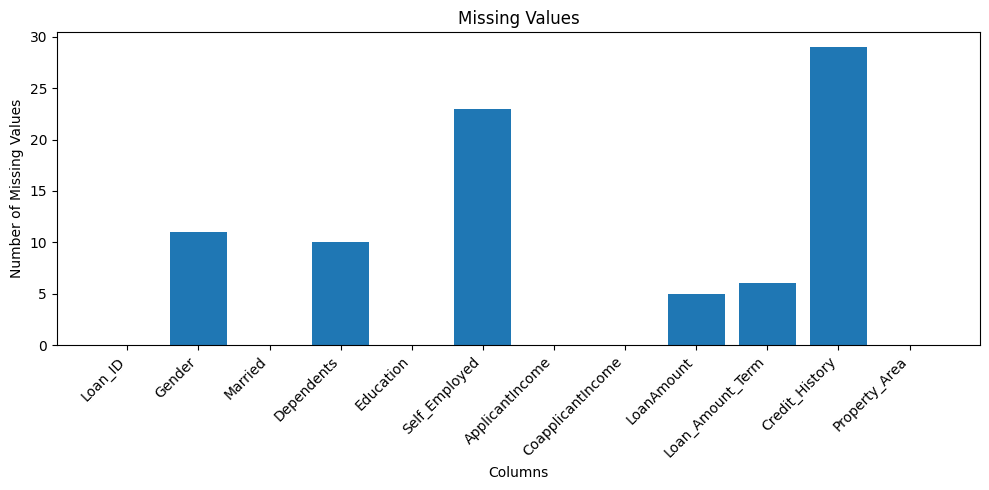


No columns have more than 50% missing values.

Numerical columns:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
------------------------------------------------------------
MISSING VALUE IMPUTATION
Missing values imputed!
------------------------------------------------------------
OUTLIER DETECTION
ApplicantIncome: 32 outliers, percentage: 8.71934604904632
Few outliers detected.
Replaced with median (3786.0).
CoapplicantIncome: 8 outliers, percentage: 2.17983651226158
Few outliers detected.
Replaced with median (1025.0).
LoanAmount: 18 outliers, percentage: 4.904632152588556
Few outliers detected.
Replaced with median (125.0).
Loan_Amount_Term: 50 outliers, percentage: 13.623978201634879
Few outliers detected.
Replaced with median (360.0).
Credit_History: 59 outliers, percentage: 16.076294277929154
Moderate outliers detecte

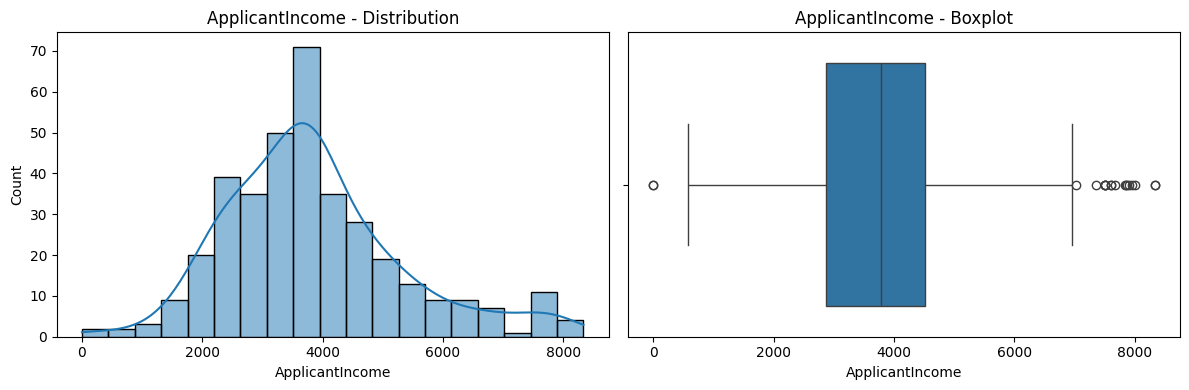

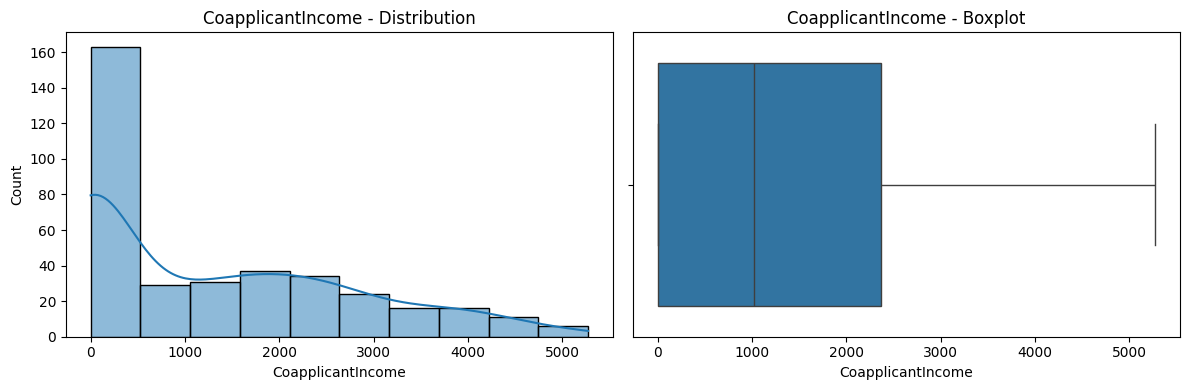

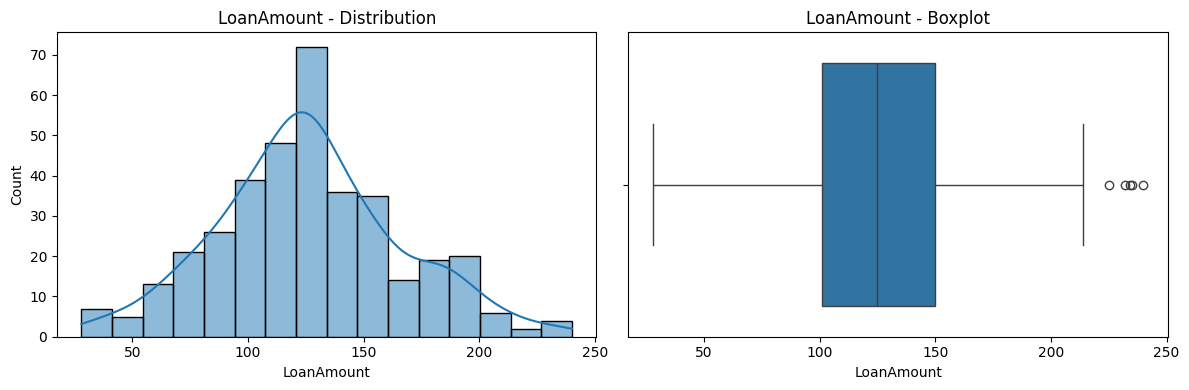

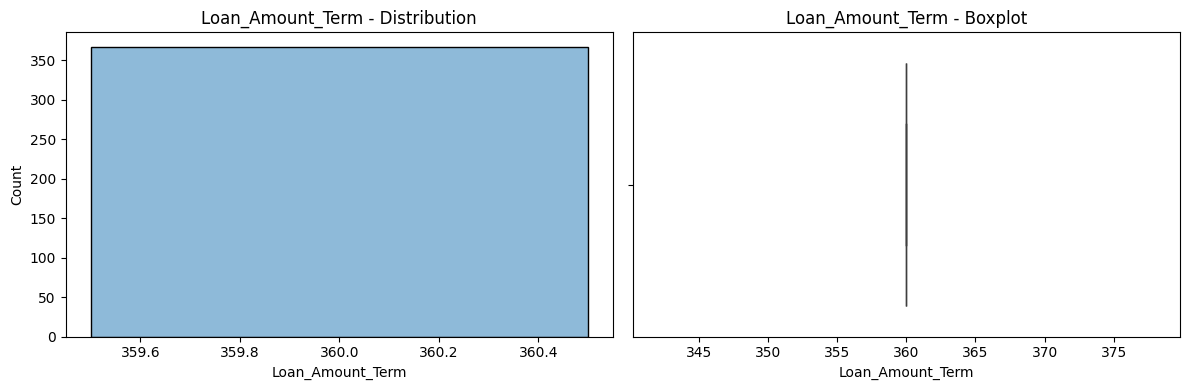

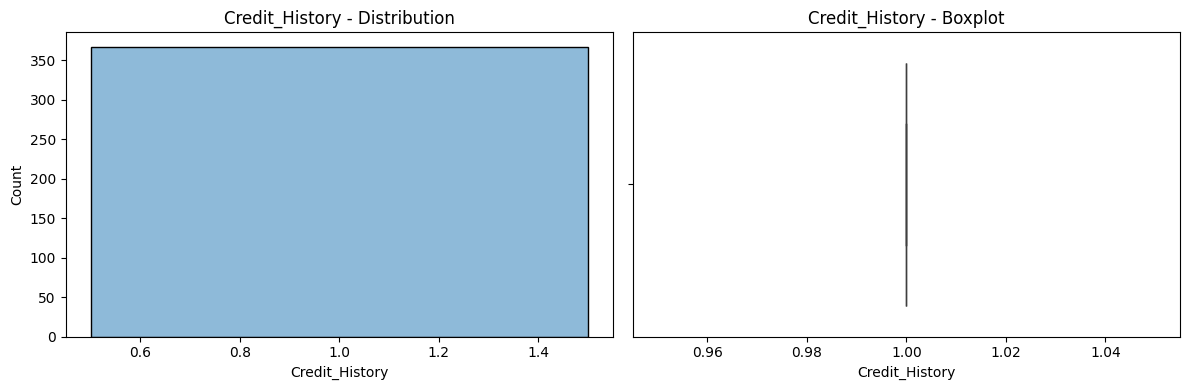

------------------------------------------------------------
NUMERICAL FEATURE TRANSFORMATION
ApplicantIncome: skewness = 0.753553594617475
Distribution is reasonably symmetric.
Applied StandardScaler.
CoapplicantIncome: skewness = 0.773721306907611
Distribution is reasonably symmetric.
Applied StandardScaler.
LoanAmount: skewness = 0.2174049064246975
Distribution is reasonably symmetric.
Applied StandardScaler.
Loan_Amount_Term: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
Credit_History: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
------------------------------------------------------------
CATEGORICAL FEATURE ANALYSIS


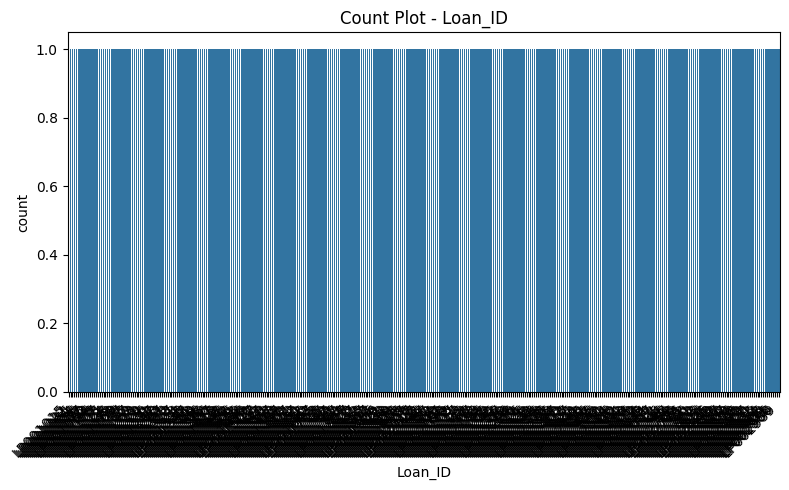

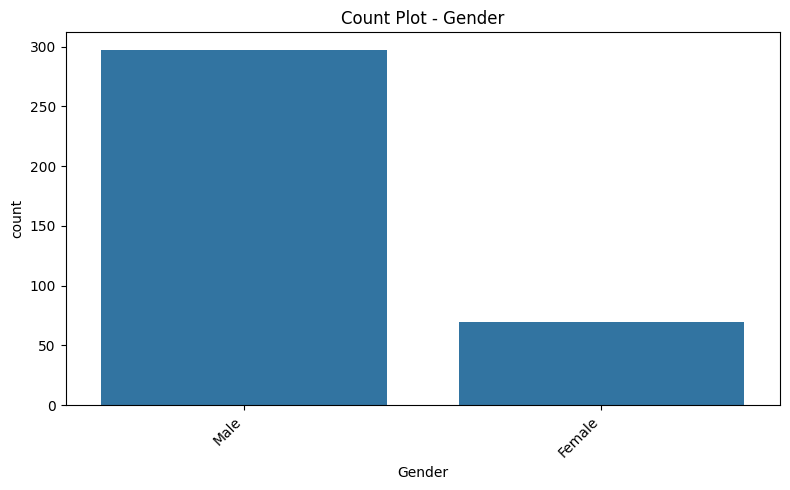

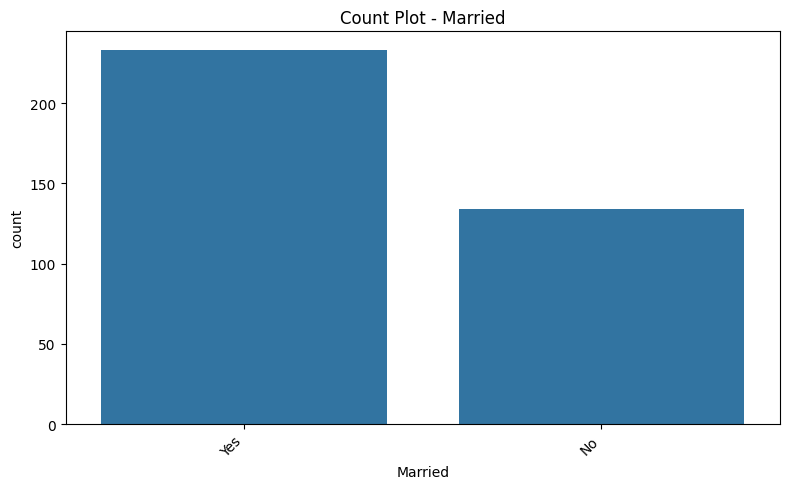

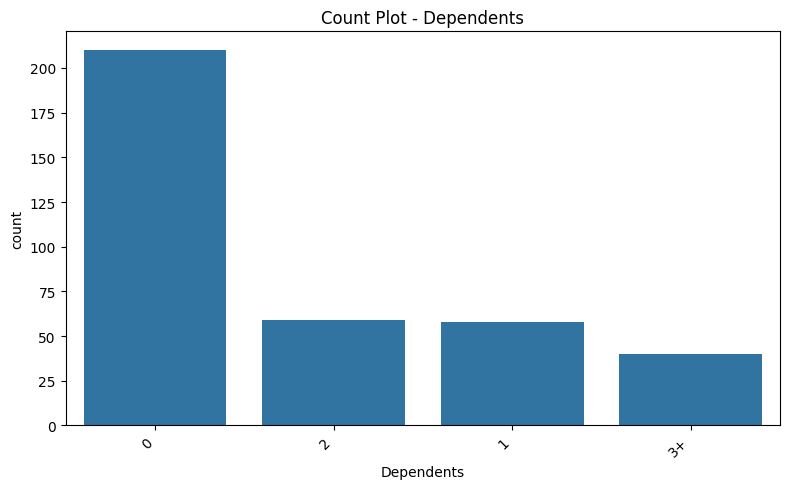

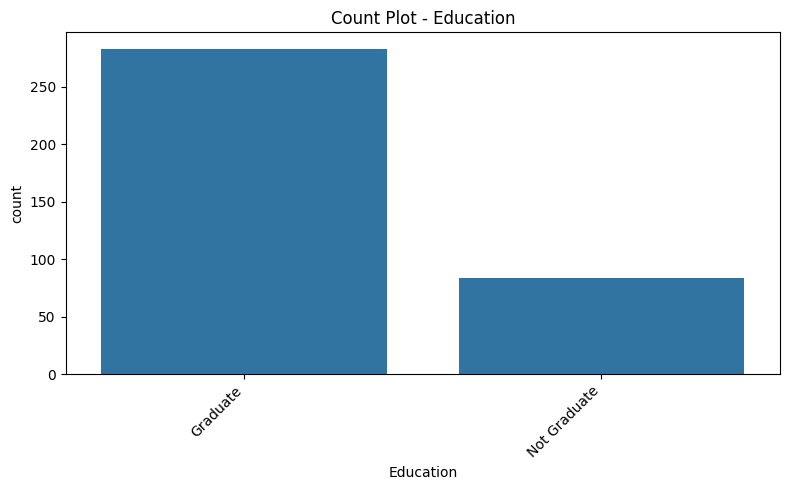

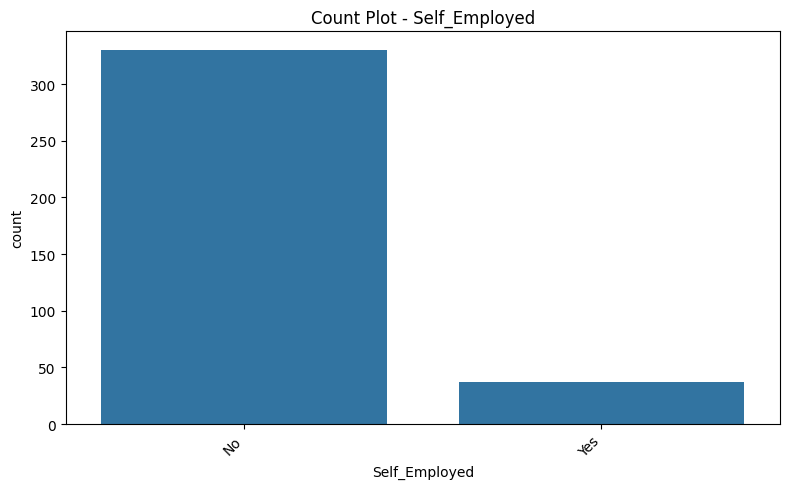

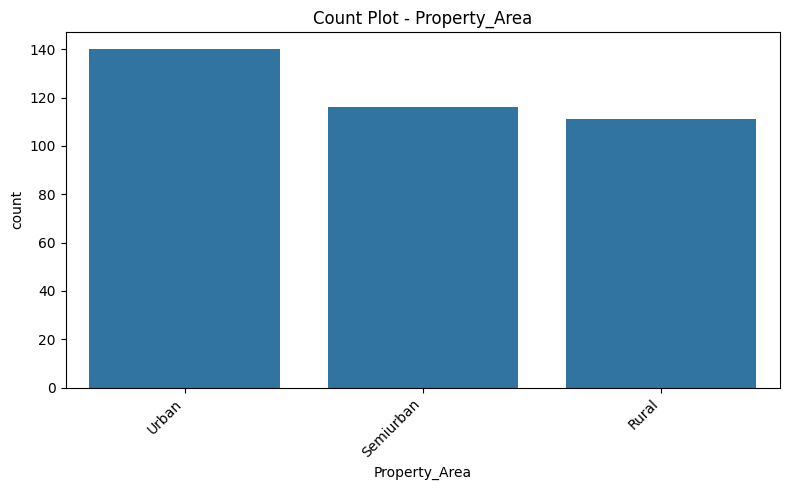

------------------------------------------------------------
CATEGORICAL ENCODING
Loan_ID: One-hot encoded 
367 categories
Gender: Binary encoding -> {'Male': 0, 'Female': 1}
Married: Binary encoding -> {'Yes': 0, 'No': 1}
Dependents: One-hot encoded 
4 categories
Education: Binary encoding -> {'Graduate': 0, 'Not Graduate': 1}
Self_Employed: Binary encoding -> {'No': 0, 'Yes': 1}
Property_Area: One-hot encoded 
3 categories
------------------------------------------------------------
FINAL DATASET
Final dimensions: (367, 380)
Remaining columns:
['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_ID_LP001022', 'Loan_ID_LP001031', 'Loan_ID_LP001035', 'Loan_ID_LP001051', 'Loan_ID_LP001054', 'Loan_ID_LP001055', 'Loan_ID_LP001056', 'Loan_ID_LP001059', 'Loan_ID_LP001067', 'Loan_ID_LP001078', 'Loan_ID_LP001082', 'Loan_ID_LP001083', 'Loan_ID_LP001094', 'Loan_ID_LP001096', 'Loan_ID_LP001099', 'Loa

In [12]:
data = eda(data)
feature_selection(data, "LoanAmount")